In [1]:
import math
import pandas as pd
from tqdm import tqdm
import numpy as np
from kaov import AOV
import matplotlib as mb
from matplotlib import pyplot as plt
from matplotlib import rc, colormaps
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.transforms as mtransforms
import re
import sys
import dill
import gzip
import itertools
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from scipy.stats import gaussian_kde
import plotnine as pltn
import scanpy as sc
import seaborn as sns
import anndata as ad
sys.setrecursionlimit(10000)

# kAOV & Scanpy

## Importing data
Malonga et al., 2025

In [45]:
filepath = '/Users/polina/Nextcloud/Postdoc_Nantes/Data/NV/'
adata = sc.read_h5ad(filepath + "rabbits_ct.h5ad")

## Scanpy & AnnData

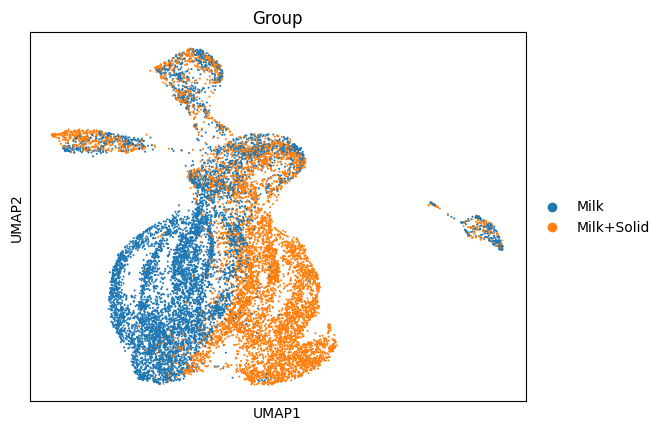

In [129]:
sc.pl.umap(adata, color='Group')

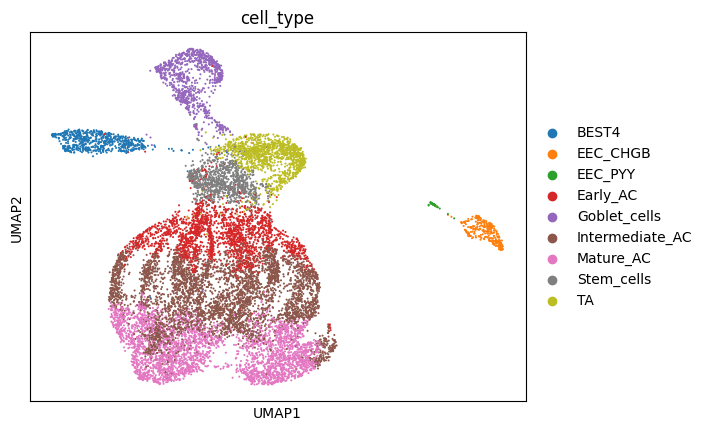

In [51]:
sc.pl.umap(adata, color='cell_type')

## kAOV

In [52]:
data = pd.DataFrame(data=adata._X, columns=adata._var.index, index=adata._obs.index)
meta_cols = ['Group', 'cell_type', 'Litter']
meta = adata._obs[['Group', 'cell_type', 'Litter']]

In [54]:
data_merged = data.join(meta)

In [111]:
gene_cols = data_merged.columns.difference(meta_cols)
formula = 'C(Group, OneHot) * C(cell_type, OneHot) + C(Litter, OneHot)'

In [112]:
form_exog = " + ".join([f'Q("{g}")' for g in gene_cols])
formula = form_exog + ' ~ C(Group, OneHot) * C(cell_type, OneHot) + C(Litter, OneHot)'
rnd_gen = np.random.default_rng(1)
kfit = AOV.from_formula(formula, data = data_merged, nystrom = True, random_gen=rnd_gen)
res = kfit.test(hypotheses = "pairwise", hypotheses_subset=['Group:cell_type',], verbose=1)

-Computing the Gram matrix...
-Testing hypotheses:


100%|████████████████████████████████████████████| 1/1 [02:36<00:00, 156.13s/it]


## UMAP-like plots of embedding projections

In [113]:
proj_umap_like = np.vstack([res.projections['Group:cell_type'][1].values,
                            res.projections['Group:cell_type'][2].values]).T

In [114]:
proj_umap_like

array([[-0.01315351, -0.09613174],
       [ 0.14918402, -0.19288621],
       [-0.0989323 ,  0.0337157 ],
       ...,
       [-0.10294646,  0.08425173],
       [-0.02143752, -0.07003955],
       [-0.07849434,  0.13906476]])

In [115]:
adata_proj = adata.copy()
adata_proj.obsm['X_umap'] = proj_umap_like

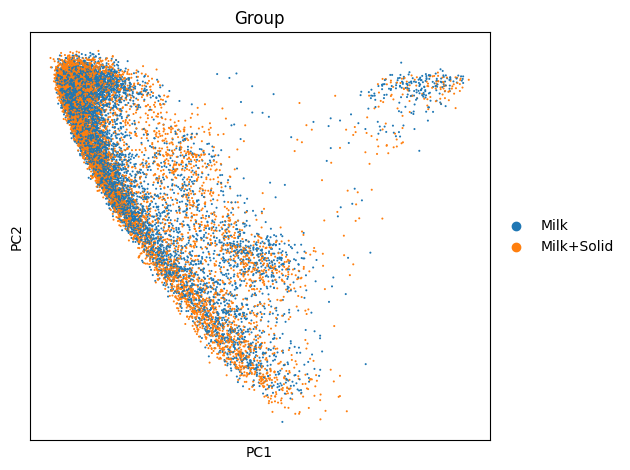

In [116]:
axs = sc.pl.umap(adata_proj, color='Group', show=False)
axs.set_xlabel('PC1')
axs.set_ylabel('PC2')
plt.tight_layout()
plt.show()

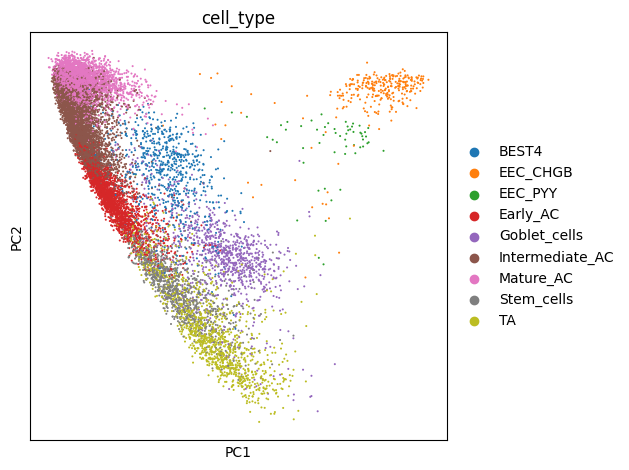

In [117]:
axs = sc.pl.umap(adata_proj, color='cell_type', show=False)
axs.set_xlabel('PC1')
axs.set_ylabel('PC2')
plt.tight_layout()
plt.show()

In [67]:
### kAOV: genewise analysis
rnd_gen = np.random.default_rng(1)

In [64]:
import warnings
warnings.filterwarnings("ignore")

In [127]:
# Exctracting CD14+ monocytes:
ct = 'Mature_AC'
data_merged_ct = data_merged[data_merged['cell_type'] == ct]

In [75]:
pval_df = pd.DataFrame(columns=gene_cols)
stat_df = pd.DataFrame(columns=gene_cols)
formula = 'C(Group, OneHot) + C(Litter, OneHot)'

it = tqdm(gene_cols)
#it = tqdm(gene_cols[:10])
for i, g in enumerate(it):
    data_g = data_merged_ct[[g, ] + ['Group', 'Litter']]
    kfit_g = AOV.from_formula(f'Q("{g}")' + ' ~ ' + formula, data=data_g, 
                              nystrom=True, n_landmarks=1000, random_gen=rnd_gen)
    res_g = kfit_g.test(hypotheses_subset=['Group',], skip_projections_and_cook=True, verbose=0)
    pval_df[g] = res_g.stats['Group']['pval']
    stat_df[g] = res_g.stats['Group']['stat']

100%|███████████████████████████████████████| 2000/2000 [13:21<00:00,  2.49it/s]


In [76]:
# Correct p-values with respect to genes and cell types:
pval_corr_df = (pval_df * pval_df.shape[1]).clip(upper=1)

In [109]:
stat_df.to_csv(filepath + 'rabbits_genewise_stat.csv')
pval_df.to_csv(filepath + 'rabbits_genewise_pval.csv')

## Genewise analysis

Get the list of top 20 marker genes:

In [77]:
t1 = 1
top_genes_ct = list(stat_df.loc[t1].sort_values()[-20:][::-1].index)

In [103]:
adata_ct = adata[adata.obs["cell_type"].str.contains("Mature")].copy()

Violin plots:

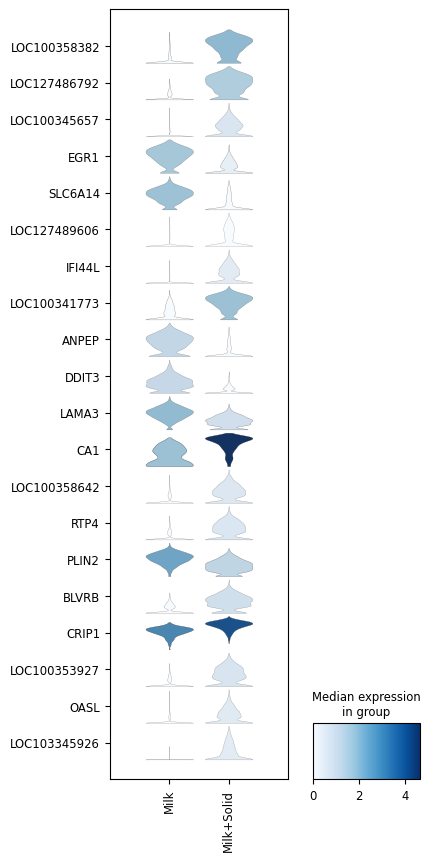

In [104]:
sc.pl.stacked_violin(adata_ct, var_names=top_genes_ct, groupby="Group", swap_axes=True, figsize=(4, 10))

Dotplots:

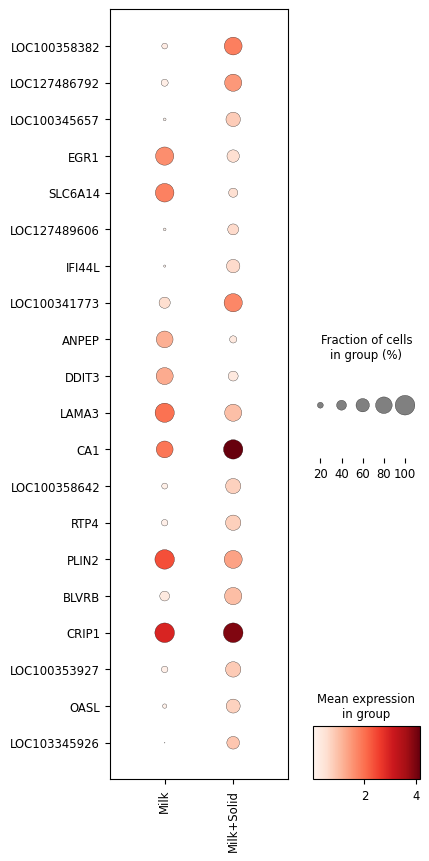

In [88]:
sc.pl.dotplot(adata_ct, var_names=top_genes_ct, groupby="Group", use_raw=True,
              swap_axes=True, figsize=(4, 10),
             )

Heatmaps:

In [92]:
sc.tl.rank_genes_groups(adata_ct, groupby="Group", groups=["Milk+Solid"], reference="Milk")
df_logfc = (sc.get.rank_genes_groups_df(adata_ct, group="Milk+Solid")[["names", "logfoldchanges"]]
            .rename(columns={"names": "gene"}).set_index('gene'))

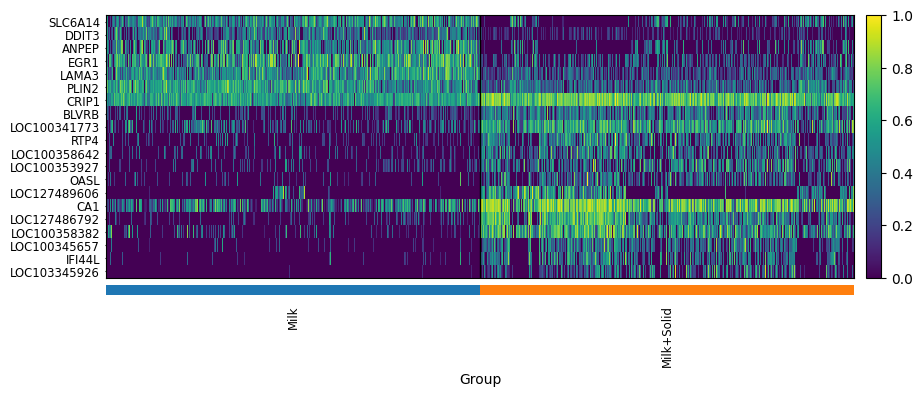

In [107]:
sc.pl.heatmap(adata_ct, groupby="Group",
              var_names=df_logfc.loc[top_genes_ct].sort_values(by='logfoldchanges').index,
              swap_axes=True, show_gene_labels=True,
              standard_scale='var',
             )

Gene expression on UMAP:

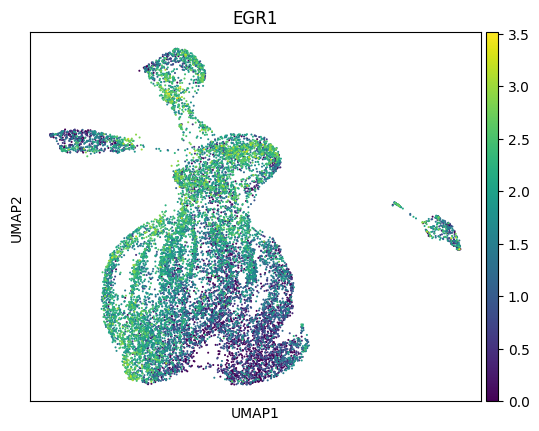

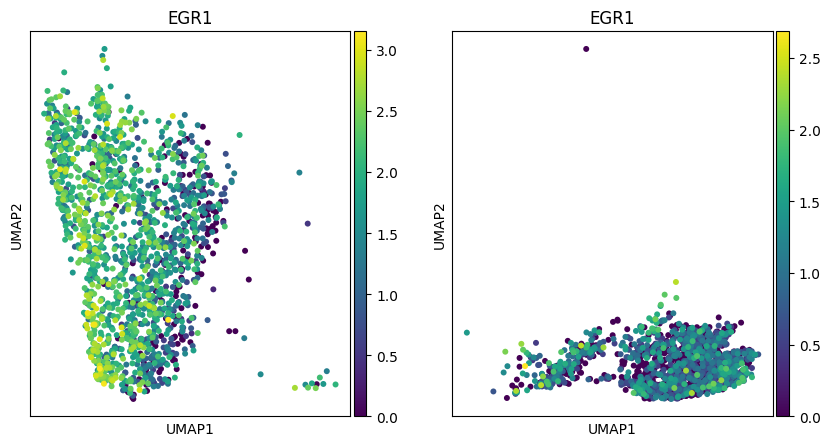

In [119]:
g = top_genes_ct[3]
sc.pl.umap(adata, color=g)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sc.pl.umap(adata[(adata.obs["cell_type"] == ct)&(adata.obs["Group"]=='Milk')].copy(), 
           color=g, ax=axs[0], show=False)
sc.pl.umap(adata[(adata.obs["cell_type"] == ct)&(adata.obs["Group"]=='Milk+Solid')].copy(), 
           color=g, ax=axs[1])
plt.show()

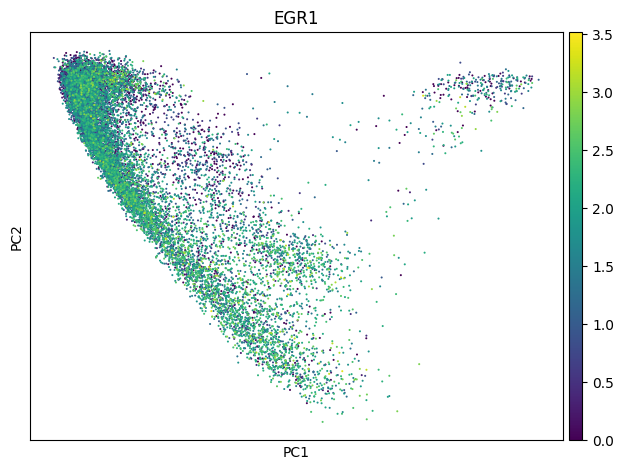

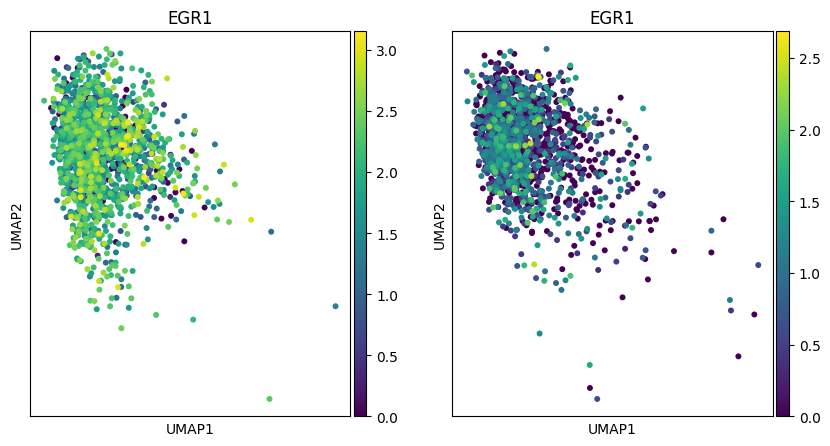

<Figure size 640x480 with 0 Axes>

In [121]:
axs = sc.pl.umap(adata_proj, color=g, show=False)
axs.set_xlabel('PC1')
axs.set_ylabel('PC2')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sc.pl.umap(adata_proj[(adata_proj.obs["cell_type"] == ct)&(adata_proj.obs["Group"]=='Milk')].copy(), 
           color=g, ax=axs[0], show=False)
sc.pl.umap(adata_proj[(adata_proj.obs["cell_type"] == ct)&(adata_proj.obs["Group"]=='Milk+Solid')].copy(), 
           color=g, ax=axs[1])
plt.tight_layout()
plt.show()

## Cook's distances

### Distances:

In [123]:
adata.obs["cook_global_1"] = res.cook_distances['Group:cell_type'][1]
adata.obs["cook_global_2"] = res.cook_distances['Group:cell_type'][2]

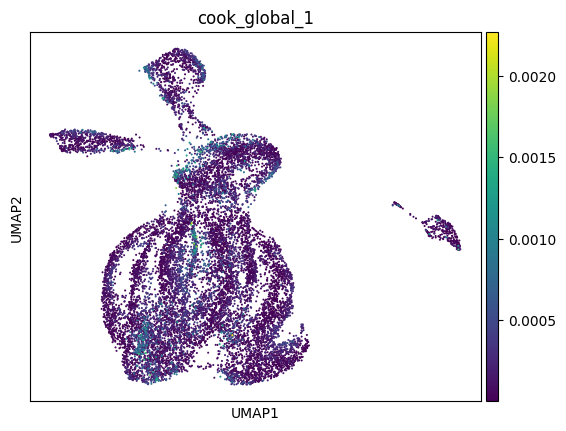

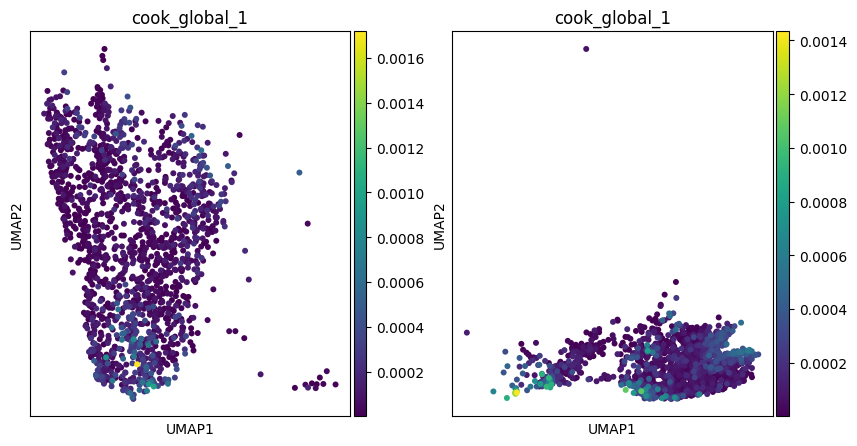

In [124]:
cook_name = "cook_global_1"
sc.pl.umap(adata, color=cook_name)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sc.pl.umap(adata[(adata.obs["cell_type"] == ct)&(adata.obs["Group"]=='Milk')].copy(), 
           color=cook_name, ax=axs[0], show=False)
sc.pl.umap(adata[(adata.obs["cell_type"] == ct)&(adata.obs["Group"]=='Milk+Solid')].copy(), 
           color=cook_name, ax=axs[1])
plt.show()

In [134]:
adata_proj.obs["cook_global_1"] = res.cook_distances['Group:cell_type'][1]
adata_proj.obs["cook_global_2"] = res.cook_distances['Group:cell_type'][2]

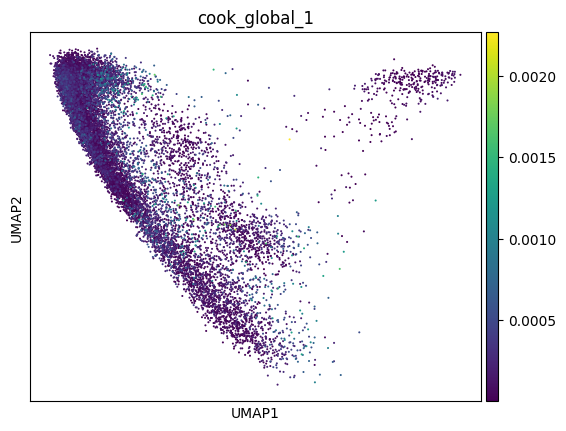

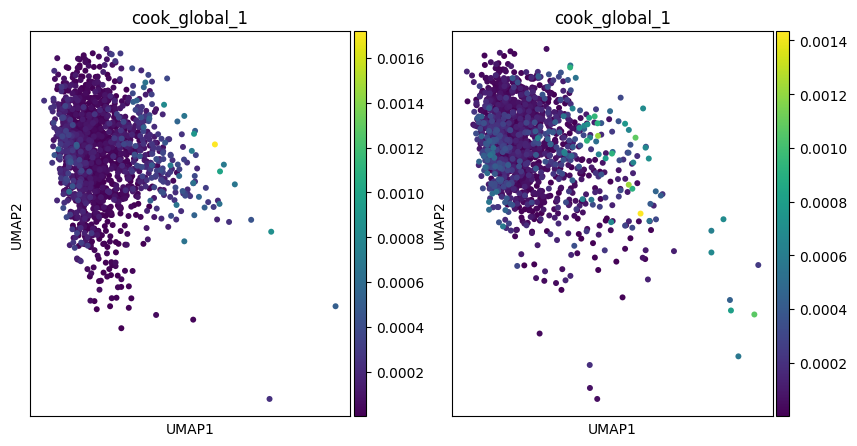

In [135]:
cook_name = "cook_global_1"
sc.pl.umap(adata_proj, color=cook_name)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sc.pl.umap(adata_proj[(adata_proj.obs["cell_type"] == ct)&(adata_proj.obs["Group"]=='Milk')].copy(), 
           color=cook_name, ax=axs[0], show=False)
sc.pl.umap(adata_proj[(adata_proj.obs["cell_type"] == ct)&(adata_proj.obs["Group"]=='Milk+Solid')].copy(), 
           color=cook_name, ax=axs[1])
plt.show()

### P-values:

In [125]:
adata.obs["cook_pval_global_1"] = res.cook_pvalues['Group:cell_type'][1] < 0.05
adata.obs["cook_pval_global_2"] = res.cook_pvalues['Group:cell_type'][2] < 0.05

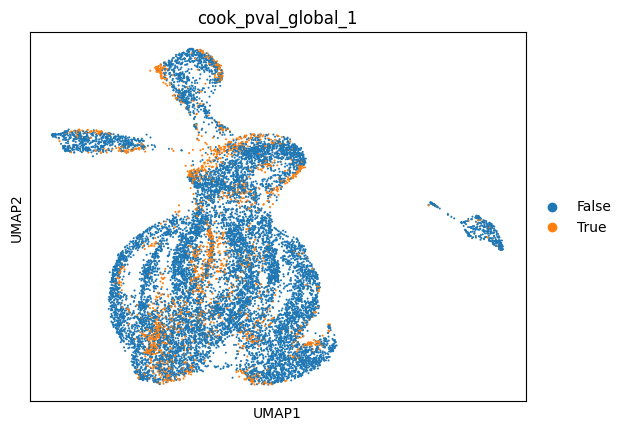

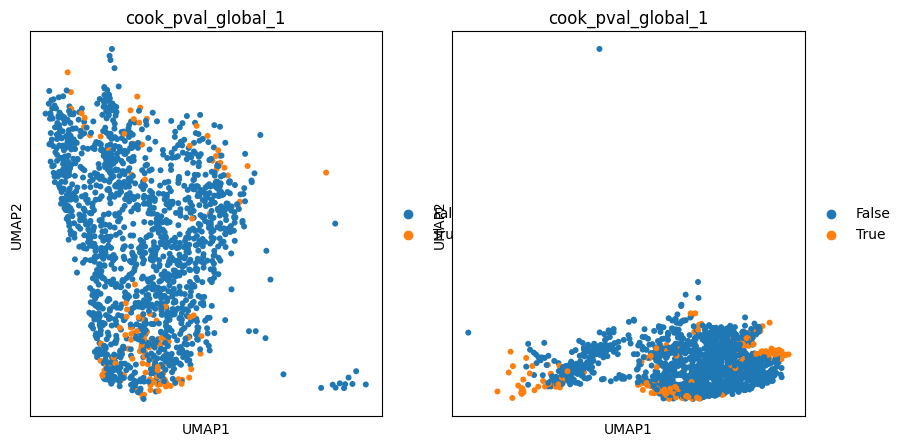

In [128]:
cook_name = "cook_pval_global_1"
sc.pl.umap(adata, color=cook_name)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sc.pl.umap(adata[(adata.obs["cell_type"] == ct)&(adata.obs["Group"]=='Milk')].copy(), 
           color=cook_name, ax=axs[0], show=False)
sc.pl.umap(adata[(adata.obs["cell_type"] == ct)&(adata.obs["Group"]=='Milk+Solid')].copy(), 
           color=cook_name, ax=axs[1])
plt.show()

In [132]:
adata_proj.obs["cook_pval_global_1"] = res.cook_pvalues['Group:cell_type'][1] < 0.05
adata_proj.obs["cook_pval_global_2"] = res.cook_pvalues['Group:cell_type'][2] < 0.05

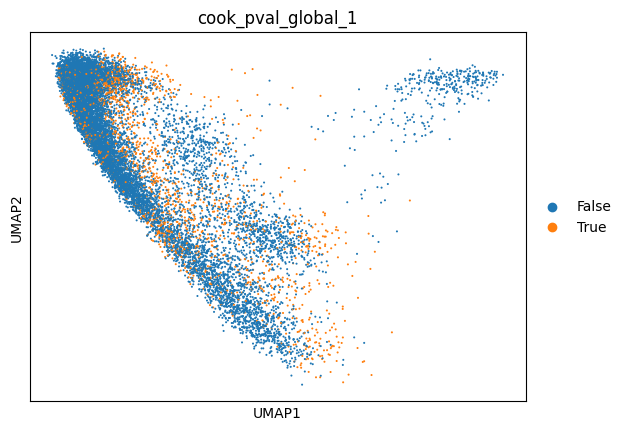

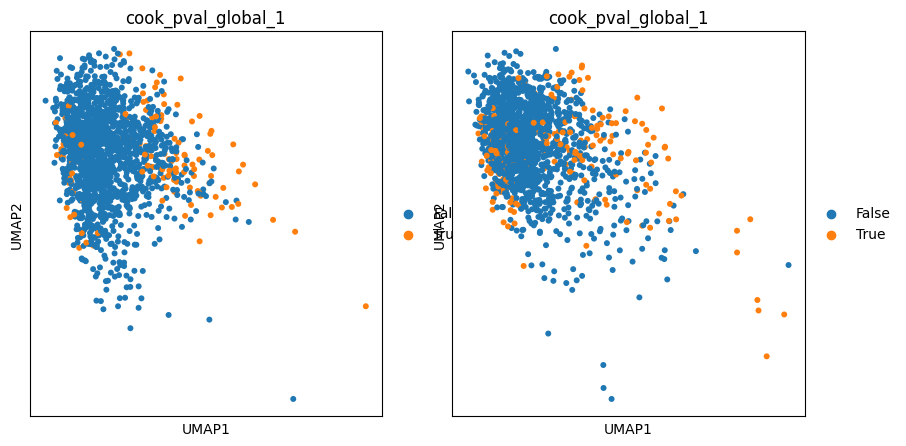

In [133]:
cook_name = "cook_pval_global_1"
sc.pl.umap(adata_proj, color=cook_name)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sc.pl.umap(adata_proj[(adata_proj.obs["cell_type"] == ct)&(adata_proj.obs["Group"]=='Milk')].copy(), 
           color=cook_name, ax=axs[0], show=False)
sc.pl.umap(adata_proj[(adata_proj.obs["cell_type"] == ct)&(adata_proj.obs["Group"]=='Milk+Solid')].copy(), 
           color=cook_name, ax=axs[1])
plt.show()

## References:
Malonga, T., Knudsen, C., Lhuillier, É., Aymard, P., Jones, E., Lencina, C., Despeyroux, M., Riant, É., Cabau, C., Ivy, A., Loving, C. L., Vialaneix, N., & Beaumont, M. (2025). A single-cell atlas of transcriptome changes in the intestinal epithelium at the suckling-to-weaning transition. Cellular and Molecular Gastroenterology and Hepatology, 20(1), 101628.